## IN_DATA
- `dat_traj`

## OUT_DATA
- `dat_map_{job}`

## VERSION

### DEV: improving optimizer, deleting only occupied edges in chuck
1. **issue**: 
    - short traj chunk might not cover some s_top, which could result an immature deletion.
2. **sol**: 
    - set lower priority to delete unoccupied edges (not even evaluating them?)
    - delete a highly occupied edge (in chunk) when tie (softmax deletion? try hard deletion first)
    - or should we delete lowly occupied edge?
3. **rationale**:
    - when tie, highly occupied edges likely are less informative than lowly occupied one. because local scores are preserved on many revisits after deletion.
4. never occupied edges should be deleted first
5. **result**:
    - delete least occupied first yields better performance curve.

### FIX: unoccupied edges is still important to encode
1. **issue 1**: 
    - removing many unoccupied edges from full map degrades performance (see job `((1,3,2),20)` or `((1,4,2),20)`)
2. **sol 1**: 
    - `init_eid_removed` is deprecated since belief distribution can still diffuse into unoccupied tile
3. **issue 2**:
    - an edge can only be deleted if ever occupied, which causes a sparse map of only unoccupied edges when mapsize is small.
4. **sol 2**:
    - use q_map instead of occ_map to delete when tie?

### WHY: still go with erasing belief info when out of boundary
1. we aim to choose an optimization scheme that minimize the boundary effects
2. strong phantom inference when wall hugging (random walks don’t have)
    - at `PI=90` + pre-encoded wall edges, `mouse performance=58%` whereas `randwalk performance=3%`.
    - hard to argue if high compressibility from mouse traj is mainly from the  wall hugging.

### WHY NOT: optimize by gradually adding edges to a empty map
1. it is hard to take advantage of chunk schedule to speed up optimization
2. optimization would start from selecting 1 out of 930 edges to add.
3. is should be evaluted on full trajectory instead of chuck because the initial encoding impact performance greatly (unlike initial deletion from the full map)

## PACKAGE

In [29]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BASH PARAMETERS

In [30]:
job_id = 420#int(sys.argv[1])

In [31]:
in_dir = project_dir / "results"
out_dir = project_dir / "results" / "data_optmap"
#
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [32]:
# load tile trajectories
dat_traj_dict = pickle.load(open(in_dir / "dat_traj_dict", "rb"))

## SPECIFY JOB BATCHES
1. Select a subset of `dat_traj_dict` with a `pi_level` as a batch of jobs to run on cluster
2. the key for reading `dat_traj_dict` is `(type_id, id_1, id_2)` to output the value `(s_traj, a_traj, occ_map, s_top, xy_traj)`
3. for loading a mouse trajectory, use:
    - `type_id = 1`
    - `id_1` = 3 or 4 or ... (mouse_id)
    - `id_2` = 0 or 1 ... or 5 (rotation_id)
4. for loading a random trajectory, use:
    - `type_id = 0`
    - `id_1` = 0 or 1 or ... (seed)
    - `id_2` = -1 (-1 to specify n/a)
5. load a job as a nested tuple `((type_id, id_1, id_2), pi_level)`

In [33]:
# TEST PILOT BATCH: 1 pi_level, 6 traj for one mouse + 5 random trajectories
pi_level = 80
job_batch_test_pilot = {
    1: ((0,0,-1), pi_level), 
    2: ((0,1,-1), pi_level), 
    3: ((0,2,-1), pi_level), 
    4: ((0,3,-1), pi_level), 
    5: ((0,4,-1), pi_level),
    6: ((1,3,0), pi_level), 
    7: ((1,3,1), pi_level), 
    8: ((1,3,2), pi_level), 
    9: ((1,3,3), pi_level), 
    10: ((1,3,4), pi_level), 
    11: ((1,3,5), pi_level),
    12: ((1,4,0), pi_level),
    13: ((1,4,1), pi_level),
    14: ((1,4,2), pi_level),
    15: ((1,4,3), pi_level),
    16: ((1,4,4), pi_level),
    17: ((1,4,5), pi_level),
}

In [34]:
# PILOT BATCH: 10 pi_level, 6 traj for one mouse x 2 + 5 random trajectories (170 jobs, 16K walltime)
seed_list = np.arange(5)
rotation_id_list = np.arange(6)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,seed,-1), pi_lev) for pi_lev in pi_level_list for seed in seed_list]
job_list_mouse_3 = [((1,3,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]
job_list_mouse_4 = [((1,4,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]

# pack
job_batch_pilot = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse_3 + job_list_mouse_4)}

# print
job_batch = job_batch_pilot
len(job_batch)

170

In [35]:
# FULL BATCH
seed_list = np.arange(n_seeds_traj)
rotation_id_list = np.arange(6)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,seed,-1), pi_lev) for pi_lev in pi_level_list for seed in seed_list]

job_list_all_mice = []
for mouse_id in mouse_ids:
    job_list_mouse = [((1,mouse_id,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]
    job_list_all_mice.extend(job_list_mouse)

# pack
job_batch_full = {i+1: job for i, job in enumerate(job_list_rand + job_list_all_mice)}

# print
len(job_batch_full)

520

## JOB BATCH TO RUN

In [36]:
job_batch = job_batch_full

## LOCAL PARAMETERS

In [37]:
debug = False
n_parallel = 25

## PREP
### setting up belief distribution propagation

In [38]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)

# prep: map
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
eid_wall, sh_wall, n_edges_wall = get_eid_wall(sas_dict, ringsize, n_tiles, e_sh_arr)
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict, sh_wall)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

In [39]:
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

## LOAD JOB

In [40]:
# check if the saved file exists
dat_path = out_dir / f"dat_map_{job_batch[job_id]}"
dat_exists = os.path.exists(dat_path)
dat_exists

True

In [41]:
key, pi_level = job_batch[job_id]
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[key]
pi = pi_all[pi_level]

## DEV

In [42]:
def get_score_map(s_traj, p_traj, s_top):
    score_mask = np.zeros_like(p_traj) + np.nan
    score_mask[range(len(s_traj)), s_traj] = 1
    score_map = np.nanmean(p_traj * score_mask, axis=0)
    score_traj = np.nansum(p_traj * score_mask, axis=1)
    #
    score_map[np.isnan(score_map)] = 0
    score_traj[np.isnan(score_traj)] = 0
    score = score_map[s_top].mean()
    score = np.around(score, 6)
    return score_map, score, score_traj

def eval_one_map(
    map,
    s_traj,
    a_traj,
    s_top,
    T_dict,
    pi,
    e_sh_arr,
    pq_mask_amb_dict,
    n_tiles,
    ringsize,
    n_edges,
    sh_dz_arr,
):
    # get pq_mask
    s_pq_mask_dict = get_s_pq_mask_dict_for_one_map(
        map, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr
    )

    # eval
    pq_traj = pq_prop_for_n_steps(
        s_traj, a_traj, T_dict, pi, s_pq_mask_dict, n_tiles, ringsize, sh_dz_arr
    )
    score_map, score, score_traj = get_score_map(s_traj, pq_traj.sum(-1), s_top)
    return score, score_map, pq_traj, score_traj

7535

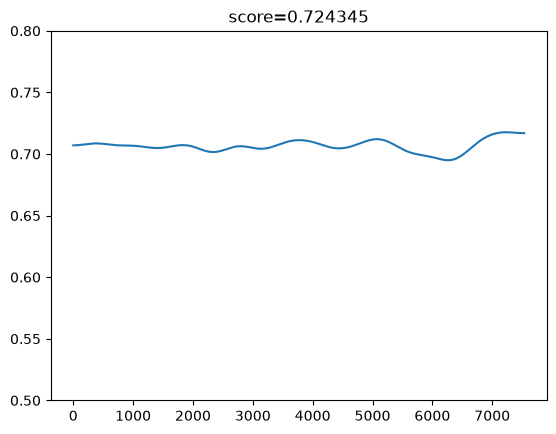

In [ ]:
job = ((1,19,0), 70)
# job = ((0,0,-1), 70)
mapsize = 74

# load
# job = ((1,mouse_id,rot_id), pi_level)
# job = ((0,0,-1), pi_level)
load_dir = project_dir / "results" / "data_optmap"
score_all, score_map_all, eid_removed = pickle.load(open(load_dir / f"dat_map_{job}", "rb"))
map_all = get_map_list_from_eid_removed(eid_removed, n_edges)

# load one iter
iter_select = list(range(931))[::-1].index(mapsize)
map = map_all[iter_select]

# score_map = score_map_all[iter_select]
# score = score_all[iter_select]

# prep
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[job[0]]
pi = pi_all[job[1]]

# run
score, score_map, pq_traj, score_traj = eval_one_map(map, s_traj, a_traj, s_top, T_dict, pi, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)

plt.title(f'score={score}')
plt.plot(gaussian_filter1d(score_traj, sigma=300))
plt.ylim(.5,.8)

# print
len(s_traj)

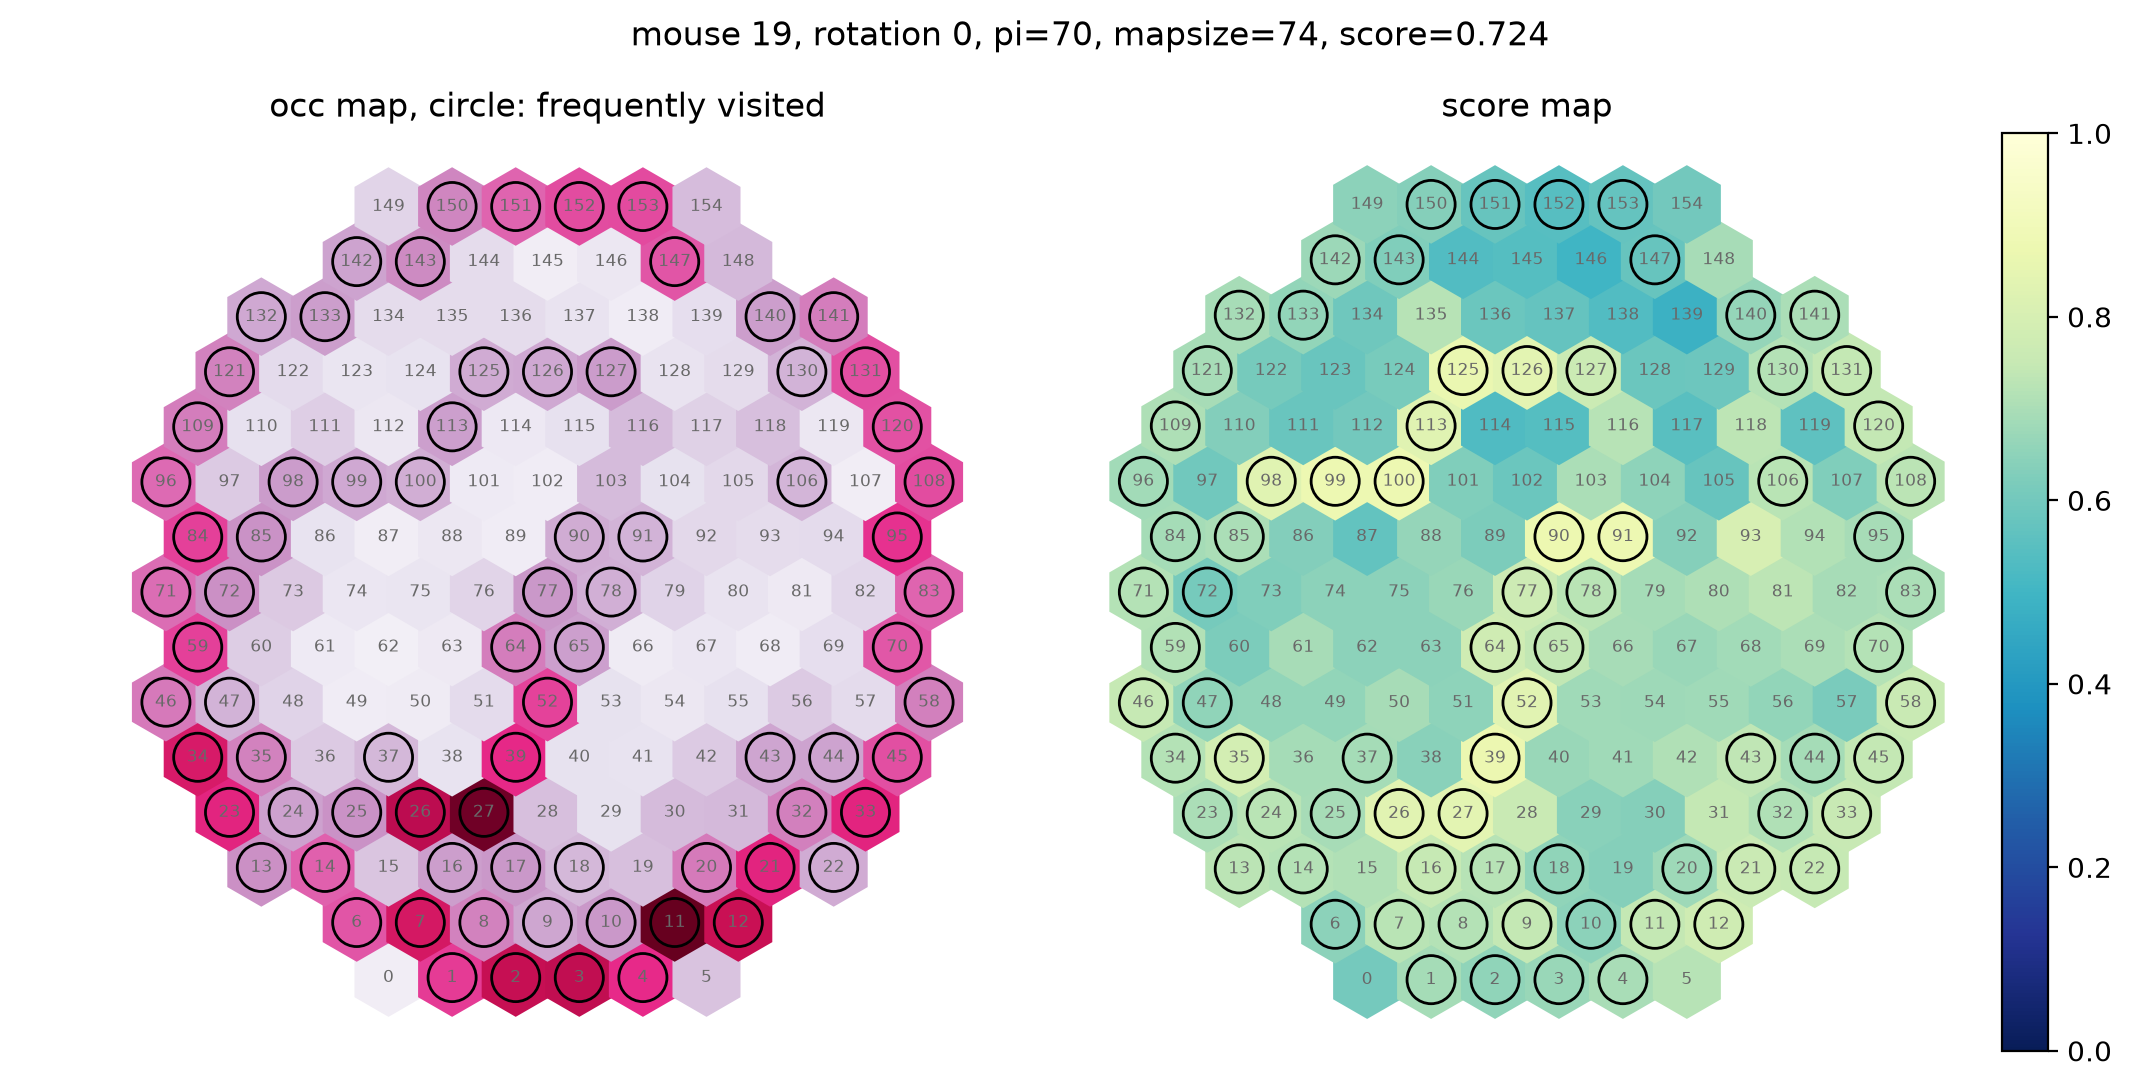

In [50]:
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

# plot
plt.figure(figsize=(11,5.5), dpi=200)
if job[0][0]==1:
    plt.suptitle(f'mouse {job[0][1]}, rotation {job[0][2]}, pi={job[1]}, mapsize={mapsize}, score={score:.3f}')
elif job[0][0]==0:
    plt.suptitle(f'randwalk {job[0][1]}, mapsize={mapsize}, score={score:.3f}')

plt.subplot(121)
plt.title('occ map, circle: frequently visited')
plt.scatter(hex_0_all, hex_1_all, c=occ_map, cmap='PuRd', marker='h', s=800, vmin=0, edgecolor='none')
plt.scatter(hex_0_all[s_top], hex_1_all[s_top], c='none', marker='o', s=300, edgecolor='k')
for (x,y), s in xy_s_dict.items():
    plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')
plt.axis('off')
plt.axis('equal')

plt.subplot(122)
plt.title('score map')
plt.scatter(hex_0_all, hex_1_all, c=score_map, cmap='YlGnBu_r', marker='h', s=800, vmin=0, vmax=1, edgecolor='none')
plt.colorbar()
plt.scatter(hex_0_all[s_top], hex_1_all[s_top], c='none', marker='o', s=300, edgecolor='k')
for (x,y), s in xy_s_dict.items():
    plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')
plt.axis('off')
plt.axis('equal')

# setting
plt.axis('off')
plt.tight_layout()